# Credit Risk Prediction using Machine Learning

## Project Overview

This project aims to predict whether a borrower is classified as a good or bad credit risk using machine learning techniques. Financial institutions use credit risk models to evaluate loan applications and minimize potential losses from defaults.

The project involves data preprocessing, feature engineering, model development, performance evaluation, and feature importance analysis using structured financial data.



In [6]:
import pandas as pd

df = pd.read_csv("german_credit_data.csv")

print(df.shape)

df.head()

(1000, 11)


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [7]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [8]:
df["Risk"].value_counts()

,count
Risk,
good,700
bad,300


In [9]:
df.shape

(1000, 11)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [11]:
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


## Exploratory Data Analysis (EDA)

The objective of this stage is to understand the distribution of borrower characteristics and identify patterns that may influence credit risk.

Key questions explored:

- How are good and bad credit risks distributed?
- What is the age profile of borrowers?
- How are credit amounts distributed?
- Do bad-risk borrowers tend to borrow larger amounts?

These insights help guide feature engineering and model development.

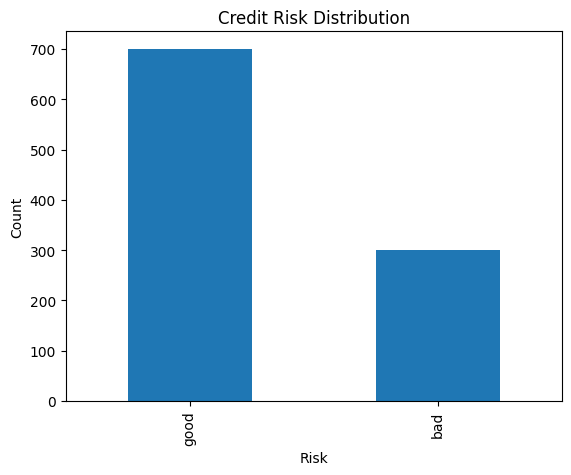

In [12]:
import matplotlib.pyplot as plt

df["Risk"].value_counts().plot(kind="bar")

plt.title("Credit Risk Distribution")
plt.xlabel("Risk")
plt.ylabel("Count")

plt.show()

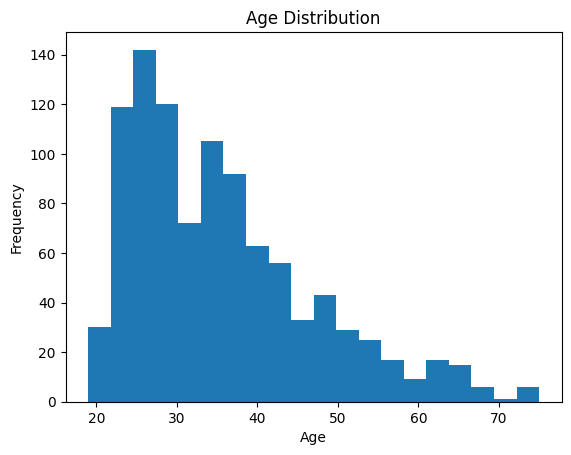

In [13]:
plt.hist(df["Age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

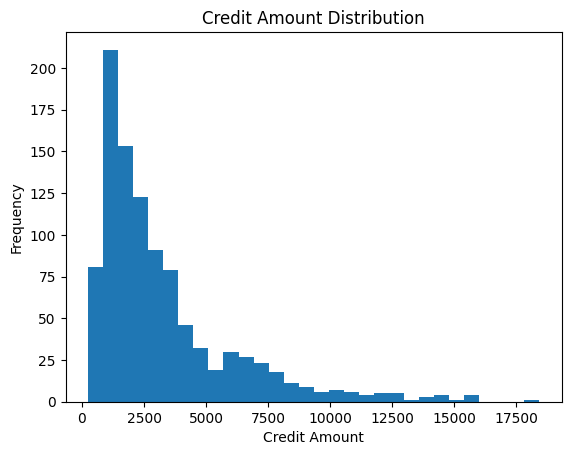

In [14]:
plt.hist(df["Credit amount"], bins=30)

plt.title("Credit Amount Distribution")
plt.xlabel("Credit Amount")
plt.ylabel("Frequency")

plt.show()

In [15]:
df.groupby("Risk")["Credit amount"].mean()

,Credit amount
Risk,
bad,3938.126667
good,2985.457143


## Key Observations from EDA

Several useful patterns emerged during exploratory analysis:

- The dataset contains more good-risk borrowers than bad-risk borrowers.
- Credit amounts show considerable variation across applicants.
- Loan duration and repayment burden appear to influence credit risk.
- Missing values are present in account-related features and require preprocessing.

Based on these findings, the next step is to clean the data and engineer additional features that may improve predictive performance.

In [16]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [17]:
df["Saving accounts"] = df["Saving accounts"].fillna("Unknown")

df["Checking account"] = df["Checking account"].fillna("Unknown")

In [18]:
df.isnull().sum()

,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,0
Checking account,0
Credit amount,0
Duration,0
Purpose,0
Risk,0


## Feature Engineering

Feature engineering involves creating new variables that may help machine learning models better capture patterns related to borrower credit risk.

Two additional features are created:

- Credit_Per_Month: Represents the monthly repayment burden by dividing credit amount by loan duration.
- Young_Borrower: Indicates whether a borrower is younger than 30 years old.

These engineered features are intended to improve model interpretability and predictive performance.

In [19]:
df["Credit_Per_Month"] = (
    df["Credit amount"] / df["Duration"]
)

In [20]:
df["Young_Borrower"] = (
    df["Age"] < 30
).astype(int)

### Observation

The Credit_Per_Month feature captures repayment burden, which is often a strong indicator of financial stress. Young_Borrower provides a simple demographic indicator that may influence borrowing behavior and creditworthiness.

In [21]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk,Credit_Per_Month,Young_Borrower
0,67,male,2,own,Unknown,little,1169,6,radio/TV,good,194.833333,0
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad,123.979167,1
2,49,male,1,own,little,Unknown,2096,12,education,good,174.666667,0
3,45,male,2,free,little,little,7882,42,furniture/equipment,good,187.666667,0
4,53,male,2,free,little,little,4870,24,car,bad,202.916667,0


## Data Encoding

Machine learning algorithms require numerical input. Therefore, categorical variables are converted into numerical representations using one-hot encoding.

The target variable (Risk) is also converted into binary form:

- Good Risk → 1
- Bad Risk → 0

In [22]:
df["Risk"] = df["Risk"].map({
    "good": 1,
    "bad": 0
})

In [23]:
df["Risk"].value_counts()

,count
Risk,
1,700
0,300


In [24]:
df = pd.get_dummies(
    df,
    drop_first=True
)

In [25]:
df.head()

,Age,Job,Credit amount,Duration,Risk,Credit_Per_Month,Young_Borrower,Sex_male,Housing_own,Housing_rent,...,Checking account_little,Checking account_moderate,Checking account_rich,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,67,2,1169,6,1,194.833333,0,True,True,False,...,True,False,False,False,False,False,False,True,False,False
1,22,2,5951,48,0,123.979167,1,False,True,False,...,False,True,False,False,False,False,False,True,False,False
2,49,1,2096,12,1,174.666667,0,True,True,False,...,False,False,False,False,False,True,False,False,False,False
3,45,2,7882,42,1,187.666667,0,True,False,False,...,True,False,False,False,False,False,True,False,False,False
4,53,2,4870,24,0,202.916667,0,True,False,False,...,True,False,False,True,False,False,False,False,False,False


## Train-Test Split

The dataset is divided into training and testing sets.

- Training Set (80%): Used to train machine learning models.
- Testing Set (20%): Used to evaluate model performance on unseen data.

A fixed random state is used to ensure reproducibility.

In [26]:
X = df.drop("Risk", axis=1)

y = df["Risk"]

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
X_train.shape
X_test.shape

(200, 23)

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Logistic Regression Model

Logistic Regression serves as a baseline classification model. Since it is sensitive to differences in feature scales, the numerical features are standardized using StandardScaler before training.

The model predicts whether a borrower belongs to the good-risk or bad-risk category.

In [30]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000, random_state=42)

In [31]:
pred_lr = lr.predict(X_test_scaled)

In [32]:
probs_lr = lr.predict_proba(X_test_scaled)[:,1]

## Random Forest Model

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive performance and reduce overfitting.

Unlike Logistic Regression, Random Forest does not require feature scaling and can capture non-linear relationships within the data.

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

In [34]:
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [35]:
pred_rf = rf.predict(X_test)

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

In [37]:
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [38]:
pred_rf = rf.predict(X_test)

# Model Evaluation

Model performance is evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

These metrics provide a comprehensive assessment of classification performance, particularly in datasets with class imbalance.

In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, pred_rf))
print("Precision:", precision_score(y_test, pred_rf))
print("Recall   :", recall_score(y_test, pred_rf))
print("F1 Score :", f1_score(y_test, pred_rf))

Accuracy : 0.785
Precision: 0.7803468208092486
Recall   : 0.9642857142857143
F1 Score : 0.8626198083067093


In [40]:
from sklearn.metrics import roc_auc_score

rf_probs = rf.predict_proba(X_test)[:,1]

rf_auc = roc_auc_score(
    y_test,
    rf_probs
)

print("ROC-AUC:", rf_auc)

ROC-AUC: 0.7414285714285714


# Feature Importance Analysis

Feature importance analysis helps identify which borrower characteristics contribute most to the model's predictions.

Understanding these factors improves model interpretability and provides insights into the drivers of credit risk.

In [41]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

top_features = importance.sort_values(
    ascending=False
).head(10)

print(top_features)

Credit_Per_Month             0.174893
Credit amount                0.160085
Duration                     0.126882
Age                          0.119022
Checking account_little      0.073979
Job                          0.041408
Checking account_moderate    0.039112
Saving accounts_little       0.035212
Purpose_radio/TV             0.025841
Young_Borrower               0.025073
dtype: float64


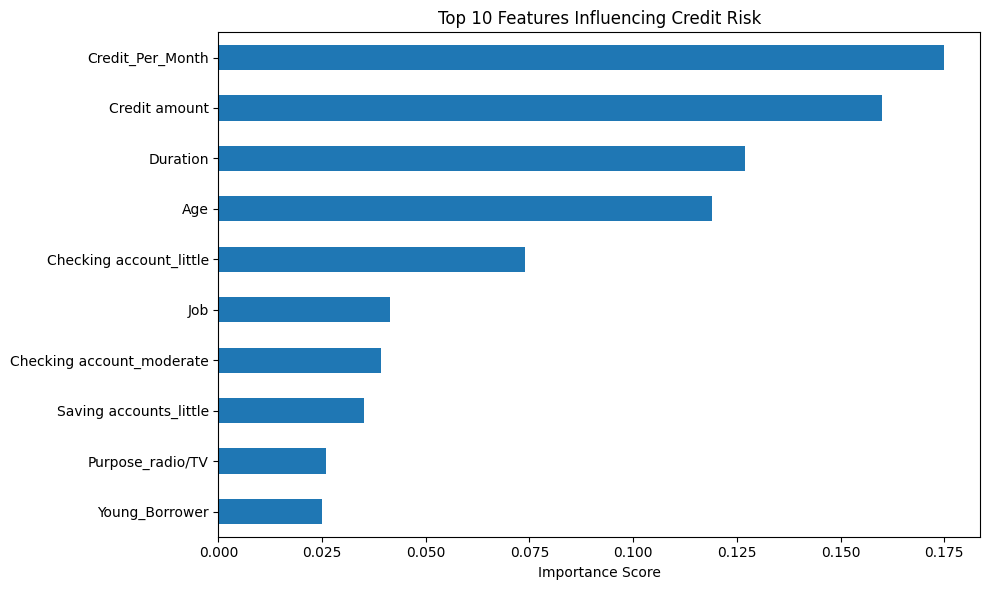

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

top_features.sort_values().plot(kind="barh")

plt.title("Top 10 Features Influencing Credit Risk")
plt.xlabel("Importance Score")

plt.tight_layout()

plt.savefig("feature_importance.png", dpi=300)

plt.show()

### Interpretation

The analysis indicates that repayment burden (Credit_Per_Month), credit amount, loan duration, and borrower age are among the most influential predictors of borrower credit risk.

These variables appear to play a significant role in determining whether an applicant is classified as a good-risk or bad-risk borrower.

# Cross Validation

To evaluate model robustness, 5-fold cross validation was performed using ROC-AUC as the evaluation metric.

Cross validation reduces dependence on a single train-test split and provides a more reliable estimate of model performance across different subsets of the dataset.


In [45]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print(scores)
print(scores.mean())

[0.76666667 0.77309524 0.74678571 0.74392857 0.74666667]
0.7554285714285714



### Results

The model achieved an average ROC-AUC score of approximately 0.755 across five validation folds, indicating consistent predictive performance and good generalization capability.

### Fold Scores

- Fold 1: 0.767
- Fold 2: 0.773
- Fold 3: 0.747
- Fold 4: 0.744
- Fold 5: 0.747

# Hyperparameter Optimization

GridSearchCV was used to identify the optimal Random Forest configuration by testing multiple combinations of model parameters.

The search evaluated different values for:

- Number of Trees (n_estimators)
- Maximum Tree Depth (max_depth)




In [46]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators":[100,200,300],
    "max_depth":[5,10,15]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=5,
    scoring="roc_auc"
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 5, 'n_estimators': 100}


### Best Parameters

- max_depth = 5
- n_estimators = 100

The optimized configuration provided the strongest balance between predictive performance and model complexity.

# Final Results Summary

| Metric | Value |
|----------|----------|
| Accuracy | 78.5% |
| Precision | 78.0% |
| Recall | 96.4% |
| F1 Score | 86.3% |
| ROC-AUC | 0.741 |
| Cross-Validated ROC-AUC | 0.755 |

### Key Findings

- Credit_Per_Month was the strongest predictor of borrower credit risk.
- Credit amount and loan duration significantly influenced classification outcomes.
- Borrower age contributed meaningfully to model predictions.
- Cross-validation confirmed that the model generalized consistently across multiple data splits.
- Hyperparameter optimization indicated that simpler Random Forest configurations provided better generalization performance.

# Conclusion

This project demonstrated the application of machine learning techniques to credit risk prediction using structured financial data.

The workflow included data preprocessing, feature engineering, model development, cross-validation, and hyperparameter optimization.

The final model achieved a cross-validated ROC-AUC score of approximately 0.755 while identifying repayment burden, credit amount, loan duration, and borrower age as key indicators of creditworthiness.

These findings illustrate how machine learning can support financial institutions in assessing borrower risk and making informed lending decisions.